In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Create a simple regression dataset

data = pd.DataFrame({
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Exam_Score": [35, 40, 48, 52, 60, 65, 72, 78, 85, 92]
})

data

,Hours_Studied,Exam_Score
0,1,35
1,2,40
2,3,48
3,4,52
4,5,60
5,6,65
6,7,72
7,8,78
8,9,85
9,10,92


In [4]:
X = data[["Hours_Studied"]]
y = data["Exam_Score"]

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

Features (X):
   Hours_Studied
0              1
1              2
2              3
3              4
4              5
5              6
6              7
7              8
8              9
9             10

Target (y):
0    35
1    40
2    48
3    52
4    60
5    65
6    72
7    78
8    85
9    92
Name: Exam_Score, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8, 1)
X_test shape: (2, 1)
y_train shape: (8,)
y_test shape: (2,)


In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficient: 6.275862068965519
Intercept: 28.232758620689644


In [7]:
y_pred = model.predict(X_test)

print("Actual values:   ", y_test.values)
print("Predicted values:", y_pred)

Actual values:    [85 40]
Predicted values: [84.71551724 40.78448276]


In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

MSE: 0.3481718192627796
RMSE: 0.5900608606430184
MAE: 0.5344827586206904
R² Score: 0.999312253196518


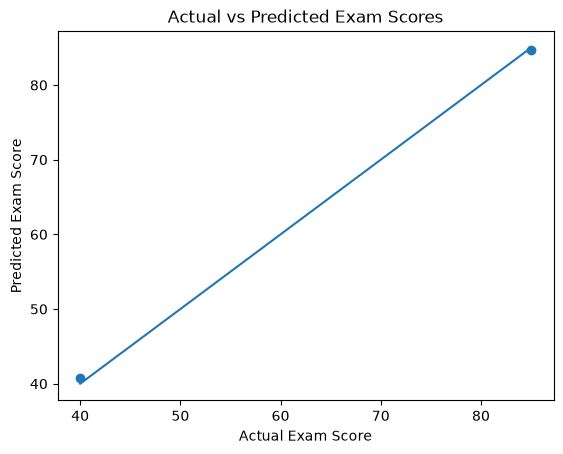

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

In [10]:
residuals = y_test - y_pred

print("Residuals:", residuals.values)

Residuals: [ 0.28448276 -0.78448276]


In [11]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Ridge model trained successfully!")
print("Ridge predictions:", ridge_pred)

Ridge model trained successfully!
Ridge predictions: [84.34322034 41.15677966]


In [12]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("Lasso model trained successfully!")
print("Lasso predictions:", lasso_pred)

Lasso model trained successfully!
Lasso predictions: [84.66724138 40.83275862]


In [13]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("Lasso model trained successfully!")
print("Lasso predictions:", lasso_pred)

Lasso model trained successfully!
Lasso predictions: [84.66724138 40.83275862]


In [14]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

results

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.348172,0.590061,0.534483,0.999312
1,Ridge Regression,0.884749,0.940611,0.906780,0.998252
2,Lasso Regression,0.402108,0.634120,0.582759,0.999206
